# ⚙️ Notebook 02 — Feature Engineering
## Predictive Maintenance AIoT Pipeline

**Objectif :** Créer de nouvelles features à partir des insights de l'EDA pour améliorer la précision du modèle ML.

**Features à créer :**
- Différences et variations de température
- Rolling statistics (fenêtres glissantes)
- Lag features (valeurs passées)
- Features composites (puissance, taux d'usure)
- Encodage du type de machine

---

## 1. Imports & Chargement des données

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette("husl")

# Charger le dataset brut
df = pd.read_csv('../data/raw/ai4i2020.csv')

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Features originales : {list(df.columns)}")
df.head()

✅ Dataset chargé : 10,000 lignes × 14 colonnes
   Features originales : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Nettoyage & Préparation
> On supprime les colonnes inutiles et on encode les variables catégorielles

In [5]:
# Supprimer colonnes non utiles pour le ML
df_clean = df.drop(columns=['UDI', 'Product ID'])

# Encoder le type de machine (L=0, M=1, H=2)
le = LabelEncoder()
df_clean['Type_encoded'] = le.fit_transform(df_clean['Type'])
print(f"Encodage Type : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Renommer les colonnes pour simplifier
df_clean = df_clean.rename(columns={
    'Air temperature [K]'       : 'air_temp',
    'Process temperature [K]'   : 'process_temp',
    'Rotational speed [rpm]'    : 'rotational_speed',
    'Torque [Nm]'               : 'torque',
    'Tool wear [min]'           : 'tool_wear',
    'Machine failure'           : 'failure'
})

print(f"\n✅ Colonnes après nettoyage :")
print(list(df_clean.columns))
print(f"\nShape : {df_clean.shape}")
df_clean.head()

Encodage Type : {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

✅ Colonnes après nettoyage :
['Type', 'air_temp', 'process_temp', 'rotational_speed', 'torque', 'tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_encoded']

Shape : (10000, 13)


,Type,air_temp,process_temp,rotational_speed,torque,tool_wear,failure,TWF,HDF,PWF,OSF,RNF,Type_encoded
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,2
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1


## 3. Features Thermiques
> L'EDA a montré que la température est un facteur clé dans les pannes HDF (Heat Dissipation Failure)

✅ Features thermiques créées :
        air_temp  process_temp  temp_diff  temp_variation  temp_ratio
count  10000.000     10000.000  10000.000        10000.00   10000.000
mean     300.005       310.006     10.001            0.00       1.033
std        2.000         1.484      1.001            0.08       0.003
min      295.300       305.700      7.600           -0.30       1.025
25%      298.300       308.800      9.300           -0.10       1.031
50%      300.100       310.100      9.800            0.00       1.033
75%      301.500       311.100     11.000            0.10       1.037
max      304.500       313.800     12.100            0.30       1.041


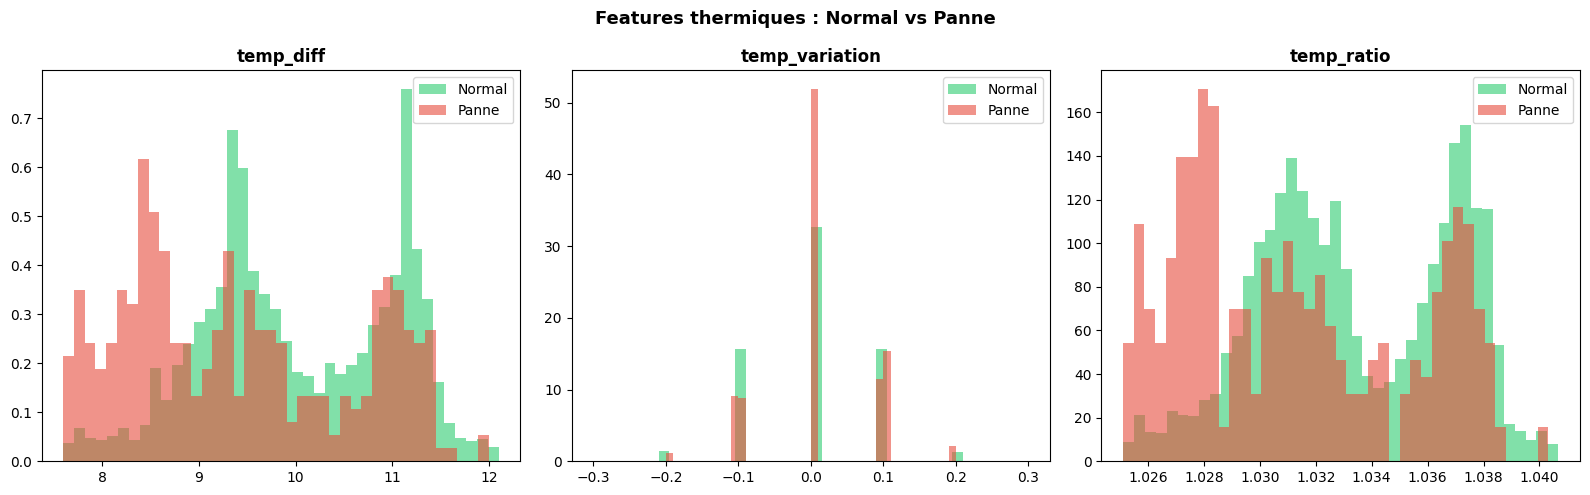

In [6]:
# Différence entre températures (écart thermique)
df_clean['temp_diff'] = df_clean['process_temp'] - df_clean['air_temp']

# Variation de la température process (dérivée discrète)
df_clean['temp_variation'] = df_clean['process_temp'].diff().fillna(0)

# Ratio températures
df_clean['temp_ratio'] = df_clean['process_temp'] / df_clean['air_temp']

# Vérification
print("✅ Features thermiques créées :")
print(df_clean[['air_temp', 'process_temp', 'temp_diff', 'temp_variation', 'temp_ratio']].describe().round(3))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, color in zip(axes,
    ['temp_diff', 'temp_variation', 'temp_ratio'],
    ['#3498db', '#e74c3c', '#2ecc71']):
    normal = df_clean[df_clean['failure']==0][feat]
    panne  = df_clean[df_clean['failure']==1][feat]
    ax.hist(normal, bins=40, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    ax.hist(panne,  bins=40, alpha=0.6, color='#e74c3c', label='Panne',  density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend()

plt.suptitle('Features thermiques : Normal vs Panne', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fe_01_thermal_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Features Mécaniques Composites
> La puissance et le taux d'usure sont des indicateurs physiques directs de la santé machine

✅ Features mécaniques créées :
           power  wear_rate  torque_wear_interaction  thermal_efficiency
count  10000.000  10000.000                10000.000           10000.000
mean   59967.147      0.071                 4314.665            6057.325
std    10193.094      0.043                 2826.568            1205.800
min    10966.800      0.000                    0.000            1068.212
25%    53105.400      0.035                 1963.650            5204.742
50%    59883.900      0.070                 4012.950            5988.523
75%    66873.750      0.106                 6279.000            6832.509
max    99980.400      0.185                16497.000           11689.999


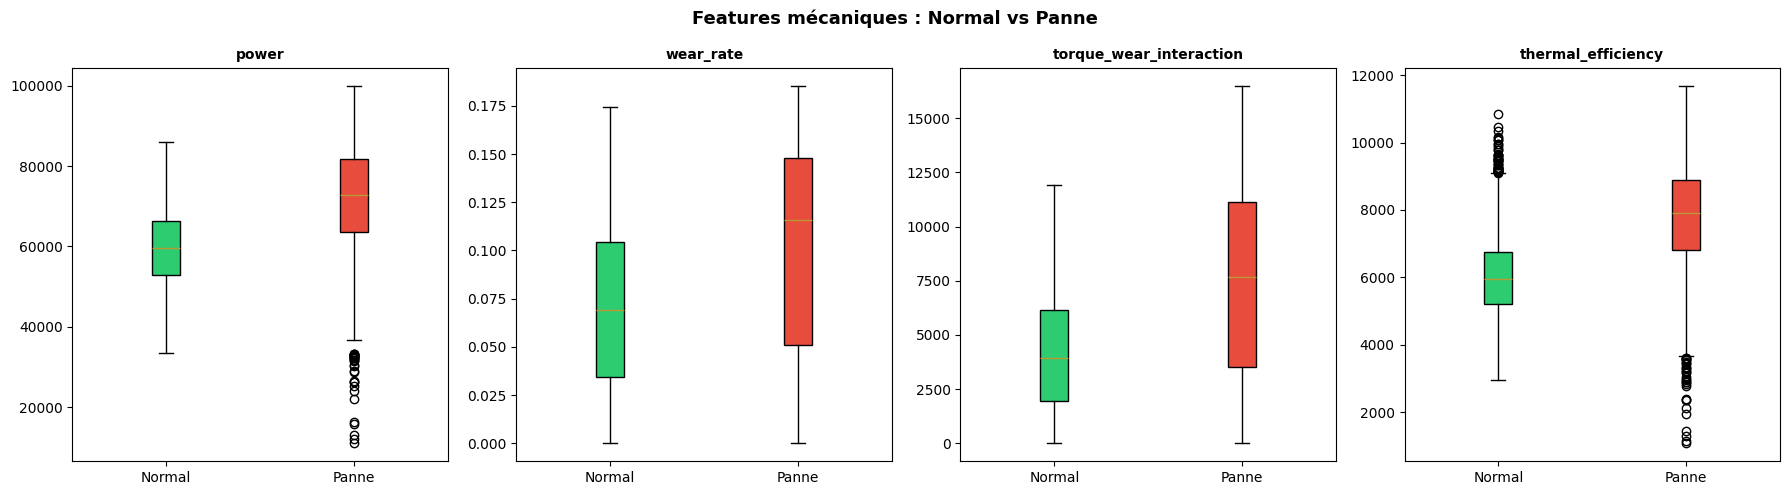

In [7]:
# Puissance mécanique (P = torque × vitesse angulaire)
df_clean['power'] = df_clean['torque'] * df_clean['rotational_speed']

# Taux d'usure normalisé
df_clean['wear_rate'] = df_clean['tool_wear'] / (df_clean['rotational_speed'] + 1e-6)

# Interaction torque × usure (stress mécanique cumulé)
df_clean['torque_wear_interaction'] = df_clean['torque'] * df_clean['tool_wear']

# Efficacité thermique (ratio puissance / température)
df_clean['thermal_efficiency'] = df_clean['power'] / (df_clean['temp_diff'] + 1e-6)

print("✅ Features mécaniques créées :")
print(df_clean[['power', 'wear_rate', 'torque_wear_interaction', 'thermal_efficiency']].describe().round(3))

# Visualisation power vs failure
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
feats = ['power', 'wear_rate', 'torque_wear_interaction', 'thermal_efficiency']

for ax, feat in zip(axes, feats):
    data = [df_clean[df_clean['failure']==0][feat].values,
            df_clean[df_clean['failure']==1][feat].values]
    bp = ax.boxplot(data, labels=['Normal', 'Panne'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(feat, fontweight='bold', fontsize=10)

plt.suptitle('Features mécaniques : Normal vs Panne', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fe_02_mechanical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Rolling Statistics (Fenêtres Glissantes)
> Ces features capturent les tendances et la variabilité sur les dernières mesures — essentielles pour détecter une dégradation progressive

✅ 14 rolling features créées :
   torque_roll_mean_5
   torque_roll_std_5
   rotational_speed_roll_mean_5
   rotational_speed_roll_std_5
   tool_wear_roll_mean_5
   tool_wear_roll_std_5
   temp_diff_roll_mean_5
   temp_diff_roll_std_5
   torque_roll_mean_10
   torque_roll_std_10
   rotational_speed_roll_mean_10
   rotational_speed_roll_std_10
   temp_diff_roll_mean_10
   temp_diff_roll_std_10


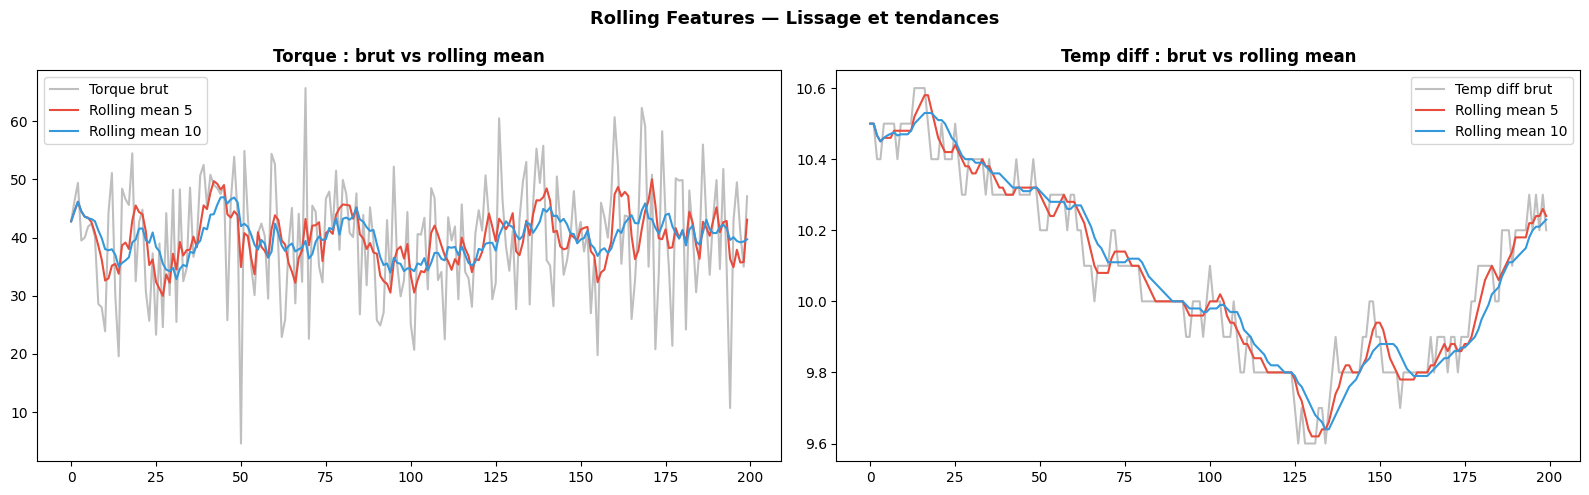

In [8]:
# Fenêtre de 5 points
for col in ['torque', 'rotational_speed', 'tool_wear', 'temp_diff']:
    df_clean[f'{col}_roll_mean_5']  = df_clean[col].rolling(5,  min_periods=1).mean()
    df_clean[f'{col}_roll_std_5']   = df_clean[col].rolling(5,  min_periods=1).std().fillna(0)

# Fenêtre de 10 points
for col in ['torque', 'rotational_speed', 'temp_diff']:
    df_clean[f'{col}_roll_mean_10'] = df_clean[col].rolling(10, min_periods=1).mean()
    df_clean[f'{col}_roll_std_10']  = df_clean[col].rolling(10, min_periods=1).std().fillna(0)

rolling_feats = [c for c in df_clean.columns if 'roll' in c]
print(f"✅ {len(rolling_feats)} rolling features créées :")
for f in rolling_feats:
    print(f"   {f}")

# Visualisation rolling mean vs valeur brute
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df_clean['torque'].iloc[:200].values,      alpha=0.5, color='gray',    label='Torque brut')
axes[0].plot(df_clean['torque_roll_mean_5'].iloc[:200].values, color='#e74c3c', label='Rolling mean 5')
axes[0].plot(df_clean['torque_roll_mean_10'].iloc[:200].values, color='#3498db', label='Rolling mean 10')
axes[0].set_title('Torque : brut vs rolling mean', fontweight='bold')
axes[0].legend()

axes[1].plot(df_clean['temp_diff'].iloc[:200].values,         alpha=0.5, color='gray',    label='Temp diff brut')
axes[1].plot(df_clean['temp_diff_roll_mean_5'].iloc[:200].values, color='#e74c3c', label='Rolling mean 5')
axes[1].plot(df_clean['temp_diff_roll_mean_10'].iloc[:200].values, color='#3498db', label='Rolling mean 10')
axes[1].set_title('Temp diff : brut vs rolling mean', fontweight='bold')
axes[1].legend()

plt.suptitle('Rolling Features — Lissage et tendances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fe_03_rolling_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Lag Features (Valeurs Passées)
> Le modèle a besoin de "voir" l'historique récent — lag features = mémoire temporelle

In [10]:
# Lag features pour les colonnes critiques
for col in ['tool_wear', 'torque', 'temp_diff', 'power']:
    df_clean[f'{col}_lag1'] = df_clean[col].shift(1).bfill()
    df_clean[f'{col}_lag3'] = df_clean[col].shift(3).bfill()
    df_clean[f'{col}_lag5'] = df_clean[col].shift(5).bfill()
# Delta (variation entre maintenant et avant)
df_clean['tool_wear_delta']  = df_clean['tool_wear'] - df_clean['tool_wear_lag1']
df_clean['torque_delta']     = df_clean['torque']    - df_clean['torque_lag1']
df_clean['temp_diff_delta']  = df_clean['temp_diff'] - df_clean['temp_diff_lag1']

lag_feats = [c for c in df_clean.columns if 'lag' in c or 'delta' in c]
print(f"✅ {len(lag_feats)} lag/delta features créées :")
for f in lag_feats:
    print(f"   {f}")

✅ 15 lag/delta features créées :
   tool_wear_lag1
   tool_wear_lag3
   tool_wear_lag5
   torque_lag1
   torque_lag3
   torque_lag5
   temp_diff_lag1
   temp_diff_lag3
   temp_diff_lag5
   power_lag1
   power_lag3
   power_lag5
   tool_wear_delta
   torque_delta
   temp_diff_delta


## 7. Corrélation des nouvelles features avec la target
> On vérifie que nos nouvelles features apportent réellement de l'information

🔝 Top 20 features les plus corrélées avec 'failure' :
  HDF                                      : +0.5758  ████████████████████████████
  OSF                                      : +0.5311  ██████████████████████████
  PWF                                      : +0.5228  ██████████████████████████
  TWF                                      : +0.3629  ██████████████████
  thermal_efficiency                       : +0.2250  ███████████
  torque                                   : +0.1913  █████████
  torque_wear_interaction                  : +0.1904  █████████
  power                                    : +0.1760  ████████
  torque_roll_std_5                        : +0.1324  ██████
  torque_delta                             : +0.1321  ██████
  wear_rate                                : +0.1302  ██████
  tool_wear_roll_mean_5                    : +0.1061  █████
  tool_wear                                : +0.1054  █████
  torque_roll_std_10                       : +0.1052  █████
  tool_w

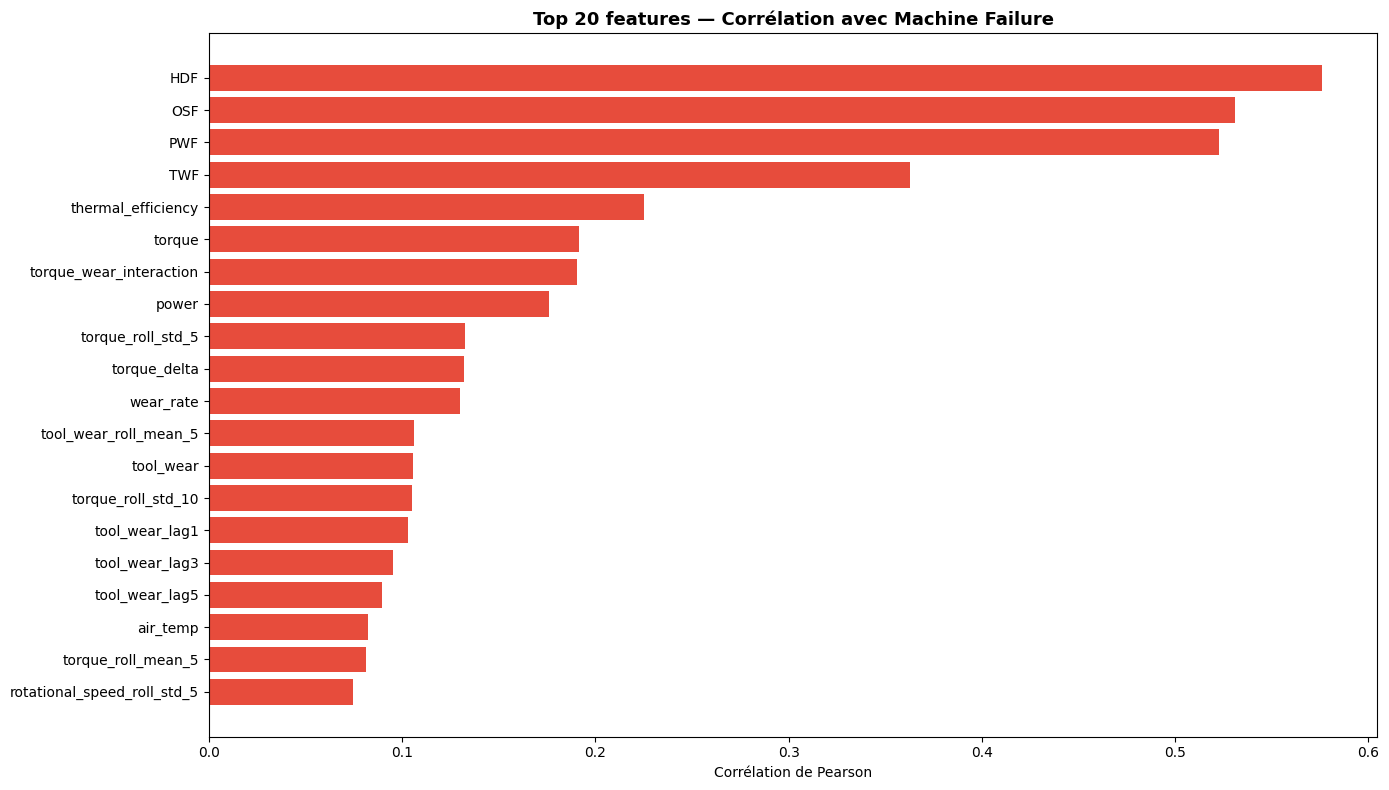

In [11]:
# Sélectionner les colonnes numériques uniquement
numeric_df = df_clean.select_dtypes(include=[np.number])

# Corrélation avec failure
corr_with_failure = numeric_df.corr()['failure'].drop('failure').sort_values(ascending=False)

# Top 20 features les plus corrélées
top20 = corr_with_failure.head(20)
bottom5 = corr_with_failure.tail(5)

print("🔝 Top 20 features les plus corrélées avec 'failure' :")
for feat, val in top20.items():
    bar = '█' * int(abs(val) * 50)
    print(f"  {feat:<40} : {val:+.4f}  {bar}")

fig, ax = plt.subplots(figsize=(14, 8))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1])
ax.axvline(0, color='white', linewidth=0.5)
ax.set_title('Top 20 features — Corrélation avec Machine Failure', fontsize=13, fontweight='bold')
ax.set_xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.savefig('../data/processed/fe_04_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Résumé des features créées

In [12]:
# Lister toutes les features finales
original_features = ['air_temp', 'process_temp', 'rotational_speed', 'torque',
                     'tool_wear', 'Type_encoded', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

new_features = [c for c in df_clean.columns
                if c not in original_features + ['Type', 'failure']]

print(f"✅ Features originales  : {len(original_features)}")
print(f"✅ Nouvelles features   : {len(new_features)}")
print(f"✅ TOTAL features       : {len(original_features) + len(new_features)}")
print(f"\nShape final du dataset : {df_clean.shape}")
print()
print("Nouvelles features créées :")
categories = {
    'Thermiques'  : [f for f in new_features if 'temp' in f],
    'Mécaniques'  : [f for f in new_features if any(k in f for k in ['power','wear_rate','interaction','efficiency'])],
    'Rolling'     : [f for f in new_features if 'roll' in f],
    'Lag/Delta'   : [f for f in new_features if 'lag' in f or 'delta' in f],
}
for cat, feats in categories.items():
    print(f"  [{cat}] ({len(feats)} features)")
    for f in feats:
        print(f"    - {f}")

✅ Features originales  : 11
✅ Nouvelles features   : 36
✅ TOTAL features       : 47

Shape final du dataset : (10000, 49)

Nouvelles features créées :
  [Thermiques] (11 features)
    - temp_diff
    - temp_variation
    - temp_ratio
    - temp_diff_roll_mean_5
    - temp_diff_roll_std_5
    - temp_diff_roll_mean_10
    - temp_diff_roll_std_10
    - temp_diff_lag1
    - temp_diff_lag3
    - temp_diff_lag5
    - temp_diff_delta
  [Mécaniques] (7 features)
    - power
    - wear_rate
    - torque_wear_interaction
    - thermal_efficiency
    - power_lag1
    - power_lag3
    - power_lag5
  [Rolling] (14 features)
    - torque_roll_mean_5
    - torque_roll_std_5
    - rotational_speed_roll_mean_5
    - rotational_speed_roll_std_5
    - tool_wear_roll_mean_5
    - tool_wear_roll_std_5
    - temp_diff_roll_mean_5
    - temp_diff_roll_std_5
    - torque_roll_mean_10
    - torque_roll_std_10
    - rotational_speed_roll_mean_10
    - rotational_speed_roll_std_10
    - temp_diff_roll_mean_10
  

## 9. Sauvegarde du dataset enrichi

In [13]:
# Supprimer la colonne Type (on garde Type_encoded)
df_final = df_clean.drop(columns=['Type'])

# Vérifier qu'il n'y a pas de NaN
print(f"Valeurs NaN restantes : {df_final.isnull().sum().sum()}")

# Sauvegarder
output_path = '../data/processed/ai4i2020_features.csv'
df_final.to_csv(output_path, index=False)

print(f"\n✅ Dataset enrichi sauvegardé :")
print(f"   Chemin  : {output_path}")
print(f"   Shape   : {df_final.shape}")
print(f"   Taille  : {df_final.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print("Prochaine étape → Notebook 03 : Entraînement ML (XGBoost + SHAP + MLflow)")

Valeurs NaN restantes : 0

✅ Dataset enrichi sauvegardé :
   Chemin  : ../data/processed/ai4i2020_features.csv
   Shape   : (10000, 48)
   Taille  : 3750.1 KB

Prochaine étape → Notebook 03 : Entraînement ML (XGBoost + SHAP + MLflow)


## 10. 📋 Conclusions

### Features les plus importantes créées :

| Feature | Type | Pourquoi c'est utile |
|---------|------|---------------------|
| `temp_diff` | Thermique | Ecart thermique = indicateur de surchauffe |
| `power` | Mécanique | Puissance réelle consommée par la machine |
| `torque_wear_interaction` | Mécanique | Stress mécanique cumulé |
| `tool_wear_delta` | Delta | Vitesse de dégradation de l'outil |
| `torque_roll_mean_10` | Rolling | Tendance du couple sur les 10 dernières mesures |
| `wear_rate` | Mécanique | Taux d'usure normalisé par la vitesse |

### Prochaine étape :
→ **Notebook 03 : Entraînement ML** — XGBoost + Isolation Forest + SHAP + MLflow